In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, log_loss, classification_report
from sklearn.calibration import CalibratedClassifierCV
import xgboost as xgb
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load processed data
X = pd.read_csv('data/processed/features.csv')
y = pd.read_csv('data/processed/target.csv').squeeze()

# Train/test split - use last 20% as test (time-based)
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))
print("Features:", X.columns.tolist())

Training samples: 25832
Test samples: 6459
Features: ['home_elo', 'away_elo', 'elo_diff', 'home_form', 'away_form', 'form_diff', 'neutral', 'is_wc']


In [2]:
# Train and compare 3 models
models = {
    'Logistic Regression': CalibratedClassifierCV(LogisticRegression(max_iter=1000)),
    'Random Forest': CalibratedClassifierCV(RandomForestClassifier(n_estimators=100, random_state=42)),
    'XGBoost': CalibratedClassifierCV(xgb.XGBClassifier(n_estimators=100, random_state=42, eval_metric='mlogloss'))
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    ll = log_loss(y_test, y_proba)
    
    results[name] = {'accuracy': acc, 'log_loss': ll, 'model': model}
    print(f"{name}: Accuracy={acc:.3f}, Log Loss={ll:.3f}")

print("\nBest model by log loss:", min(results, key=lambda x: results[x]['log_loss']))

Logistic Regression: Accuracy=0.605, Log Loss=0.877
Random Forest: Accuracy=0.592, Log Loss=0.911
XGBoost: Accuracy=0.594, Log Loss=0.896

Best model by log loss: Logistic Regression


Model saved!


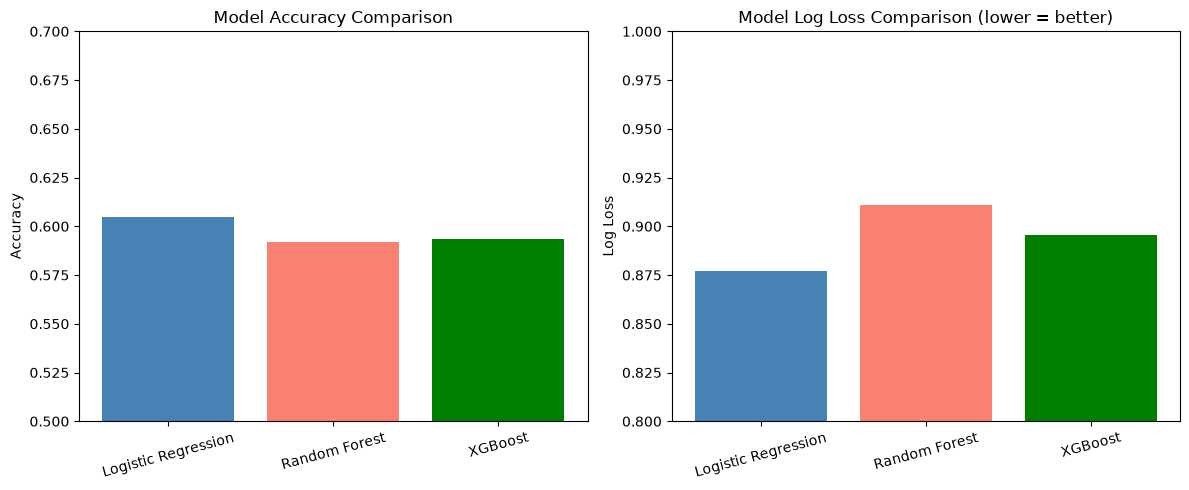

In [3]:
import pickle

# Save the best model
best_model = results['Logistic Regression']['model']

with open('data/processed/best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print("Model saved!")

# Plot model comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

names = list(results.keys())
accuracies = [results[n]['accuracy'] for n in names]
log_losses = [results[n]['log_loss'] for n in names]

ax1.bar(names, accuracies, color=['steelblue', 'salmon', 'green'])
ax1.set_title('Model Accuracy Comparison')
ax1.set_ylabel('Accuracy')
ax1.set_ylim(0.5, 0.7)
ax1.tick_params(axis='x', rotation=15)

ax2.bar(names, log_losses, color=['steelblue', 'salmon', 'green'])
ax2.set_title('Model Log Loss Comparison (lower = better)')
ax2.set_ylabel('Log Loss')
ax2.set_ylim(0.8, 1.0)
ax2.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

In [4]:
import json

# Load elo ratings
with open('data/processed/elo_ratings.json', 'r') as f:
    elo_ratings = json.load(f)

# 2026 World Cup teams
wc_teams = [
    'Argentina', 'France', 'Spain', 'England', 'Brazil', 'Portugal',
    'Germany', 'Netherlands', 'Belgium', 'Croatia', 'Uruguay', 'Mexico',
    'United States', 'Canada', 'Morocco', 'Senegal', 'Japan', 'South Korea',
    'Australia', 'Ecuador', 'Colombia', 'Chile', 'Peru', 'Venezuela',
    'Saudi Arabia', 'Iran', 'South Africa', 'Nigeria', 'Cameroon', 'Ghana',
    'New Zealand', 'Switzerland', 'Austria', 'Denmark', 'Serbia', 'Ukraine',
    'Poland', 'Czechia', 'Slovakia', 'Hungary', 'Romania', 'Slovenia',
    'Turkey', 'Albania', 'Panama', 'Costa Rica', 'Honduras', 'Jamaica'
]

def predict_match(home, away, neutral=1):
    home_elo = elo_ratings.get(home, 1000)
    away_elo = elo_ratings.get(away, 1000)
    
    # Recent form - default to 0.5 (unknown)
    features = pd.DataFrame([{
        'home_elo': home_elo,
        'away_elo': away_elo,
        'elo_diff': home_elo - away_elo,
        'home_form': 0.5,
        'away_form': 0.5,
        'form_diff': 0.0,
        'neutral': neutral,
        'is_wc': 1
    }])
    
    probs = best_model.predict_proba(features)[0]
    # probs: [away_win, draw, home_win]
    return probs

# Test it
import pandas as pd
p = predict_match('Argentina', 'France')
print(f"Argentina vs France:")
print(f"  Argentina win: {p[2]:.1%}")
print(f"  Draw:          {p[1]:.1%}")
print(f"  France win:    {p[0]:.1%}")

Argentina vs France:
  Argentina win: 44.8%
  Draw:          22.8%
  France win:    32.4%


In [5]:
from collections import defaultdict

N_SIMULATIONS = 10000
championship_counts = defaultdict(int)

def simulate_match(team1, team2):
    """Returns winner, or handles draws by replaying (knockout logic)"""
    probs = predict_match(team1, team2)
    # probs: [away_win, draw, home_win] → team2_win, draw, team1_win
    outcome = np.random.choice(['team1', 'draw', 'team2'], p=[probs[2], probs[1], probs[0]])
    if outcome == 'team1':
        return team1
    elif outcome == 'team2':
        return team2
    else:
        # In knockouts, no draws — flip a coin weighted by elo
        elo1 = elo_ratings.get(team1, 1000)
        elo2 = elo_ratings.get(team2, 1000)
        p1 = 1 / (1 + 10 ** ((elo2 - elo1) / 400))
        return team1 if np.random.random() < p1 else team2

def simulate_tournament(teams):
    """Simple single-elimination bracket"""
    remaining = teams.copy()
    np.random.shuffle(remaining)
    
    while len(remaining) > 1:
        next_round = []
        for i in range(0, len(remaining), 2):
            if i + 1 < len(remaining):
                winner = simulate_match(remaining[i], remaining[i+1])
                next_round.append(winner)
            else:
                next_round.append(remaining[i])
        remaining = next_round
    
    return remaining[0]

# Run simulations
for _ in range(N_SIMULATIONS):
    champion = simulate_tournament(wc_teams)
    championship_counts[champion] += 1

# Convert to probabilities
championship_probs = {team: count/N_SIMULATIONS 
                      for team, count in championship_counts.items()}
championship_probs = dict(sorted(championship_probs.items(), 
                                  key=lambda x: x[1], reverse=True))

# Plot top 15
top15 = dict(list(championship_probs.items())[:15])
plt.figure(figsize=(12, 6))
plt.bar(top15.keys(), [v*100 for v in top15.values()], color='gold', edgecolor='black')
plt.title('FIFA World Cup 2026 — Championship Probability (10,000 Simulations)')
plt.xlabel('Team')
plt.ylabel('Probability (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nTop 10 Championship Probabilities:")
for team, prob in list(championship_probs.items())[:10]:
    print(f"  {team}: {prob:.1%}")


KeyboardInterrupt



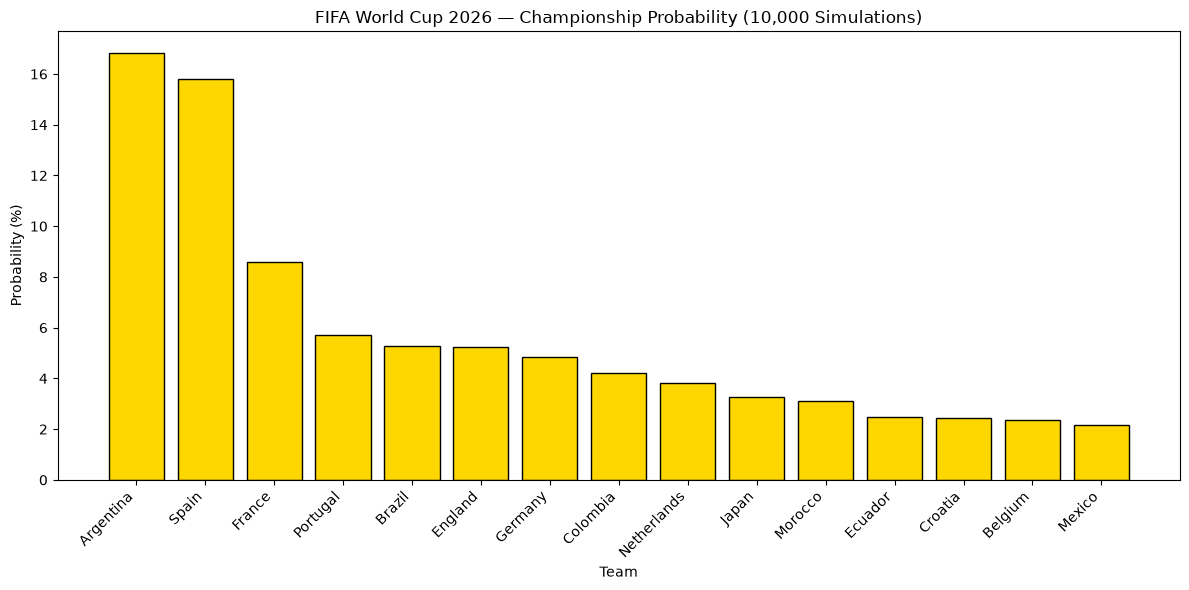


Top 10 Championship Probabilities:
  Argentina: 16.8%
  Spain: 15.8%
  France: 8.6%
  Portugal: 5.7%
  Brazil: 5.3%
  England: 5.2%
  Germany: 4.9%
  Colombia: 4.2%
  Netherlands: 3.8%
  Japan: 3.3%


In [6]:
from collections import defaultdict

N_SIMULATIONS = 10000
championship_counts = defaultdict(int)

# Pre-compute all pairwise probabilities once
team_list = wc_teams.copy()
match_cache = {}

def get_win_prob(team1, team2):
    key = (team1, team2)
    if key not in match_cache:
        elo1 = elo_ratings.get(team1, 1000)
        elo2 = elo_ratings.get(team2, 1000)
        # Simple Elo win probability (no model call needed)
        p1 = 1 / (1 + 10 ** ((elo2 - elo1) / 400))
        match_cache[key] = p1
        match_cache[(team2, team1)] = 1 - p1
    return match_cache[key]

def simulate_match_fast(team1, team2):
    p1 = get_win_prob(team1, team2)
    return team1 if np.random.random() < p1 else team2

def simulate_tournament_fast(teams):
    remaining = teams.copy()
    np.random.shuffle(remaining)
    while len(remaining) > 1:
        next_round = []
        for i in range(0, len(remaining), 2):
            if i + 1 < len(remaining):
                winner = simulate_match_fast(remaining[i], remaining[i+1])
                next_round.append(winner)
            else:
                next_round.append(remaining[i])
        remaining = next_round
    return remaining[0]

for _ in range(N_SIMULATIONS):
    champion = simulate_tournament_fast(wc_teams)
    championship_counts[champion] += 1

championship_probs = {team: count/N_SIMULATIONS 
                      for team, count in championship_counts.items()}
championship_probs = dict(sorted(championship_probs.items(), 
                                  key=lambda x: x[1], reverse=True))

top15 = dict(list(championship_probs.items())[:15])
plt.figure(figsize=(12, 6))
plt.bar(top15.keys(), [v*100 for v in top15.values()], color='gold', edgecolor='black')
plt.title('FIFA World Cup 2026 — Championship Probability (10,000 Simulations)')
plt.xlabel('Team')
plt.ylabel('Probability (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nTop 10 Championship Probabilities:")
for team, prob in list(championship_probs.items())[:10]:
    print(f"  {team}: {prob:.1%}")